In [1]:
from collections import defaultdict
from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"


## Загрузка данных


In [2]:
def load_transactions(path):
    transactions = []
    with open(path, encoding="cp1251") as f:
        for line in f:
            items = {item.strip() for item in line.strip().split(",") if item.strip()}
            if items:
                transactions.append(items)
    return transactions


DATA_PATH = "baskets.csv"
transactions = load_transactions(DATA_PATH)
print(f"Транзакций: {len(transactions)}")
print(f"Уникальных товаров: {len({i for t in transactions for i in t})}")
print(f"Средняя длина корзины: {sum(len(t) for t in transactions) / len(transactions):.2f}")


Транзакций: 7501
Уникальных товаров: 115
Средняя длина корзины: 3.91


## Apriori 


In [3]:
def _apriori_join(prev_level, k):
    candidates = set()
    m = len(prev_level)
    for i in range(m):
        for j in range(i + 1, m):
            union = prev_level[i] | prev_level[j]
            if len(union) == k:
                candidates.add(union)
    return list(candidates)


def _apriori_prune(candidates, prev_frequent, k):
    kept = []
    for cand in candidates:
        if all(frozenset(sub) in prev_frequent for sub in combinations(cand, k - 1)):
            kept.append(cand)
    return kept


def apriori(transactions, min_support, order="support_desc"):
    if order not in {"support_desc", "lex"}:
        raise ValueError('order должен быть "support_desc" или "lex"')

    n_trans = len(transactions)
    if n_trans == 0:
        return []

    min_count = min_support * n_trans
    support = {}

    item_counts = defaultdict(int)
    for basket in transactions:
        for item in basket:
            item_counts[item] += 1

    L_current = []
    for item, cnt in item_counts.items():
        if cnt >= min_count:
            itemset = frozenset([item])
            L_current.append(itemset)
            support[itemset] = cnt / n_trans
    L_current.sort(key=lambda s: tuple(sorted(s)))

    all_frequent = list(L_current)
    k = 2
    while L_current:
        candidates = _apriori_join(L_current, k)
        candidates = _apriori_prune(candidates, set(L_current), k)
        if not candidates:
            break

        cand_index = set(candidates)
        counts = defaultdict(int)
        for basket in transactions:
            if len(basket) < k:
                continue
            for comb in combinations(sorted(basket), k):
                itemset = frozenset(comb)
                if itemset in cand_index:
                    counts[itemset] += 1

        L_next = []
        for cand in candidates:
            cnt = counts[cand]
            if cnt >= min_count:
                L_next.append(cand)
                support[cand] = cnt / n_trans

        L_next.sort(key=lambda s: tuple(sorted(s)))
        all_frequent.extend(L_next)
        L_current = L_next
        k += 1

    result = [(itemset, support[itemset]) for itemset in all_frequent]
    if order == "support_desc":
        result.sort(key=lambda x: (-x[1], tuple(sorted(x[0]))))
    else:
        result.sort(key=lambda x: tuple(sorted(x[0])))
    return result


## Генерация ассоциативных правил

Для каждого частого набора длины >= 2 перебираются непустые собственные поднаборы как антецедент; консеквент - оставшиеся объекты.

In [4]:
def _fmt_itemset(itemset):
    return ", ".join(sorted(itemset))


def association_rules(frequent_itemsets, min_confidence, order="support_desc"):
    if order not in {"support_desc", "lex"}:
        raise ValueError('order должен быть "support_desc" или "lex"')

    support = {itemset: supp for itemset, supp in frequent_itemsets}
    rules = []
    for itemset, supp in frequent_itemsets:
        if len(itemset) < 2:
            continue
        items = list(itemset)
        for r in range(1, len(items)):
            for ante in combinations(items, r):
                antecedent = frozenset(ante)
                consequent = itemset - antecedent
                conf = supp / support[antecedent]
                if conf >= min_confidence:
                    rules.append(
                        {
                            "antecedent": antecedent,
                            "consequent": consequent,
                            "support": supp,
                            "confidence": conf,
                        }
                    )

    if order == "support_desc":
        rules.sort(
            key=lambda r: (
                -r["support"],
                -r["confidence"],
                tuple(sorted(r["antecedent"])),
                tuple(sorted(r["consequent"])),
            )
        )
    else:
        rules.sort(
            key=lambda r: (
                tuple(sorted(r["antecedent"])),
                tuple(sorted(r["consequent"])),
            )
        )
    return rules


def mine_association_rules(transactions, min_support, min_confidence, order="support_desc"):
    itemsets = apriori(transactions, min_support, order="support_desc")
    return association_rules(itemsets, min_confidence, order=order), itemsets


def rules_to_frame(rules):
    rows = []
    for r in rules:
        rows.append(
            {
                "правило": f"{_fmt_itemset(r['antecedent'])} → {_fmt_itemset(r['consequent'])}",
                "антецедент": _fmt_itemset(r["antecedent"]),
                "консеквент": _fmt_itemset(r["consequent"]),
                "длина A∪B": len(r["antecedent"]) + len(r["consequent"]),
                "поддержка": r["support"],
                "достоверность": r["confidence"],
            }
        )
    return pd.DataFrame(rows)


def show_df(df, formats=None):
    out = df.copy()
    if formats:
        for col, spec in formats.items():
            if col in out.columns:
                out[col] = out[col].map(lambda x, s=spec: format(x, s))
    display(out)


## Пример работы

Порог поддержки 1%, достоверность 40%. Два способа сортировки.


In [5]:
DEMO_SUPPORT = 0.01
DEMO_CONFIDENCE = 0.40

rules_by_support, itemsets_demo = mine_association_rules(
    transactions, DEMO_SUPPORT, DEMO_CONFIDENCE, order="support_desc"
)
rules_lex = association_rules(itemsets_demo, DEMO_CONFIDENCE, order="lex")

print(f"Частых наборов: {len(itemsets_demo)}")
print(f"Правил при conf ≥ {DEMO_CONFIDENCE:.0%}: {len(rules_by_support)}")

print("\nСортировка по убыванию поддержки:")
show_df(
    rules_to_frame(rules_by_support),
    {"поддержка": ".2%", "достоверность": ".2%"},
)

print("\nЛексикографическая сортировка (первые 15):")
show_df(
    rules_to_frame(rules_lex).head(15),
    {"поддержка": ".2%", "достоверность": ".2%"},
)


Частых наборов: 261
Правил при conf ≥ 40%: 19

Сортировка по убыванию поддержки:


,правило,антецедент,консеквент,длина A∪B,поддержка,достоверность
0,говяжий фарш → минеральная вода,говяжий фарш,минеральная вода,2,4.09%,41.66%
1,говяжий фарш → макароны,говяжий фарш,макароны,2,4.03%,40.98%
2,оливковое масло → минеральная вода,оливковое масло,минеральная вода,2,2.76%,41.90%
3,суп → минеральная вода,суп,минеральная вода,2,2.31%,45.65%
4,"говяжий фарш, макароны → минеральная вода","говяжий фарш, макароны",минеральная вода,3,1.72%,42.72%
5,"говяжий фарш, минеральная вода → макароны","говяжий фарш, минеральная вода",макароны,3,1.72%,42.02%
6,лосось → минеральная вода,лосось,минеральная вода,2,1.71%,40.13%
7,"макароны, шоколад → минеральная вода","макароны, шоколад",минеральная вода,3,1.64%,40.20%
8,"макароны, молоко → минеральная вода","макароны, молоко",минеральная вода,3,1.61%,43.68%
9,"молоко, шоколад → минеральная вода","молоко, шоколад",минеральная вода,3,1.40%,43.57%



Лексикографическая сортировка (первые 15):


,правило,антецедент,консеквент,длина A∪B,поддержка,достоверность
0,"блинчики, макароны → минеральная вода","блинчики, макароны",минеральная вода,3,1.17%,45.83%
1,говяжий фарш → макароны,говяжий фарш,макароны,2,4.03%,40.98%
2,говяжий фарш → минеральная вода,говяжий фарш,минеральная вода,2,4.09%,41.66%
3,"говяжий фарш, макароны → минеральная вода","говяжий фарш, макароны",минеральная вода,3,1.72%,42.72%
4,"говяжий фарш, минеральная вода → макароны","говяжий фарш, минеральная вода",макароны,3,1.72%,42.02%
5,"говяжий фарш, молоко → минеральная вода","говяжий фарш, молоко",минеральная вода,3,1.11%,50.30%
6,"говяжий фарш, шоколад → минеральная вода","говяжий фарш, шоколад",минеральная вода,3,1.09%,47.40%
7,"говяжий фарш, яйца → минеральная вода","говяжий фарш, яйца",минеральная вода,3,1.01%,50.67%
8,"замороженные овощи, макароны → минеральная вода","замороженные овощи, макароны",минеральная вода,3,1.23%,43.40%
9,"замороженные овощи, молоко → минеральная вода","замороженные овощи, молоко",минеральная вода,3,1.11%,46.89%


## Эксперементы
поддержка **10%** и достоверность **70–95%**


In [6]:
print("Сверка с порогами из формулировки задания")
itemsets_10 = apriori(transactions, 0.10)
print(
    f"min_support=10%: частых наборов {len(itemsets_10)}, "
    f"из них длины ≥ 2: {sum(1 for s, _ in itemsets_10 if len(s) >= 2)}"
)

assign_rows = []
for conf in [i / 100 for i in range(70, 100, 5)]:
    t0 = perf_counter()
    found = association_rules(itemsets_10, conf)
    elapsed = perf_counter() - t0
    assign_rows.append(
        {
            "порог достоверности": f"{conf:.0%}",
            "число правил": len(found),
            "время генерации правил, с": elapsed,
        }
    )
show_df(pd.DataFrame(assign_rows), {"время генерации правил, с": ".6f"})


Сверка с порогами из формулировки задания
min_support=10%: частых наборов 7, из них длины ≥ 2: 0


,порог достоверности,число правил,"время генерации правил, с"
0,70%,0,0.000009
1,75%,0,0.000003
2,80%,0,0.000002
3,85%,0,0.000002
4,90%,0,0.000003
5,95%,0,0.000002


Фиксированная поддержка 1%. Порог достоверности: 20%, 25%, 30%, 35%, 40%, 45%, 50%.

In [7]:
FIXED_SUPPORT = 0.01
CONF_THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

t0 = perf_counter()
itemsets_fixed = apriori(transactions, FIXED_SUPPORT)
apriori_time = perf_counter() - t0
print(f"Apriori при min_support={FIXED_SUPPORT:.0%}: {len(itemsets_fixed)} наборов за {apriori_time:.3f} с")

exp_rows = []
for conf in CONF_THRESHOLDS:
    t0 = perf_counter()
    found = association_rules(itemsets_fixed, conf, order="support_desc")
    elapsed = perf_counter() - t0
    exp_rows.append(
        {
            "порог достоверности": f"{conf:.0%}",
            "min_confidence": conf,
            "число правил": len(found),
            "время, с": elapsed,
        }
    )

rules_exp_df = pd.DataFrame(exp_rows)
show_df(rules_exp_df.drop(columns=["min_confidence"]), {"время, с": ".6f"})


Apriori при min_support=1%: 261 наборов за 0.273 с


,порог достоверности,число правил,"время, с"
0,20%,163,0.001018
1,25%,99,0.000615
2,30%,65,0.000553
3,35%,34,0.000541
4,40%,19,0.000455
5,45%,6,0.000483
6,50%,2,0.000519


### Быстродействие поиска правил при изменяемом пороге достоверности


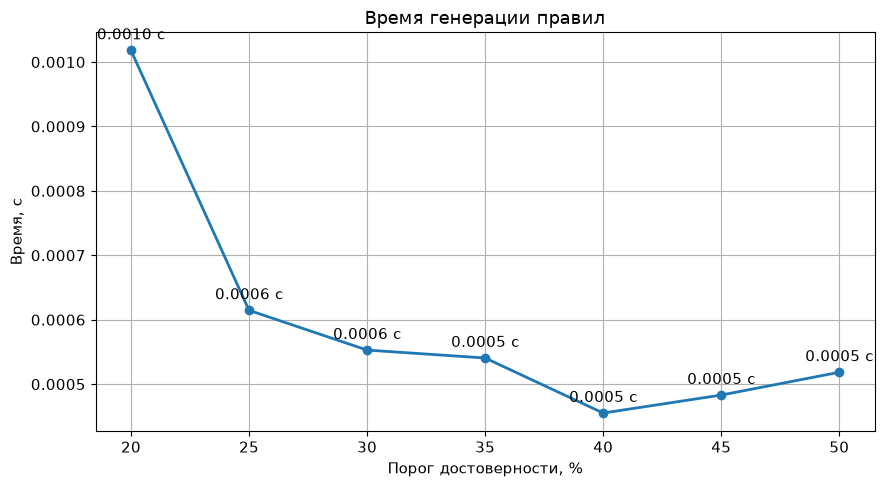

In [8]:
fig, ax = plt.subplots()
ax.plot(
    rules_exp_df["min_confidence"] * 100,
    rules_exp_df["время, с"],
    marker="o",
    linewidth=2,
)
ax.set_title("Время генерации правил")
ax.set_xlabel("Порог достоверности, %")
ax.set_ylabel("Время, с")
ax.set_xticks(rules_exp_df["min_confidence"] * 100)
for x, y in zip(rules_exp_df["min_confidence"] * 100, rules_exp_df["время, с"]):
    ax.annotate(f"{y:.4f} с", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
fig.tight_layout()
plt.show()


### Число найденных правил при изменяемом пороге достоверности


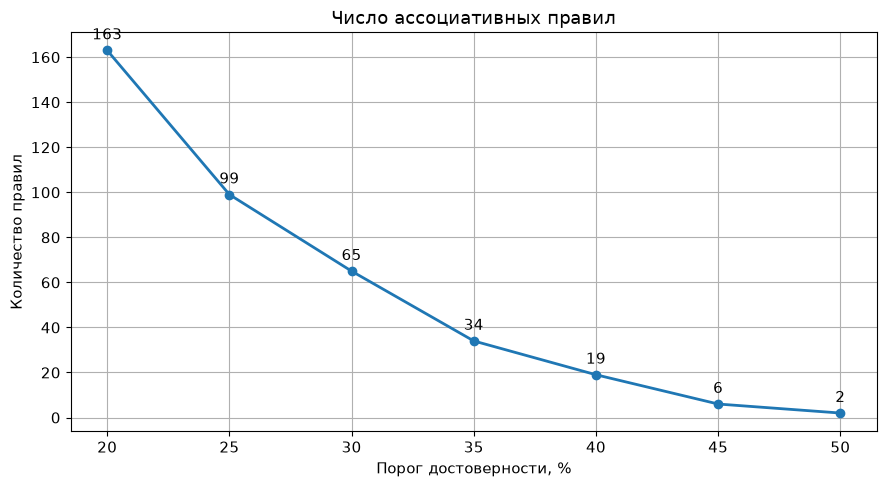

In [9]:
fig, ax = plt.subplots()
ax.plot(
    rules_exp_df["min_confidence"] * 100,
    rules_exp_df["число правил"],
    marker="o",
    linewidth=2,
)
ax.set_title("Число ассоциативных правил")
ax.set_xlabel("Порог достоверности, %")
ax.set_ylabel("Количество правил")
ax.set_xticks(rules_exp_df["min_confidence"] * 100)
for x, y in zip(rules_exp_df["min_confidence"] * 100, rules_exp_df["число правил"]):
    ax.annotate(str(int(y)), (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
fig.tight_layout()
plt.show()


## антецедент + консеквент ≤ 7

На выбранных порогах максимальная длина частого набора равна 3


In [10]:
MAX_ITEMS = 7
compact = [
    r
    for r in association_rules(itemsets_fixed, 0.40, order="support_desc")
    if len(r["antecedent"]) + len(r["consequent"]) <= MAX_ITEMS
]
print(f"Правил с длиной A∪B ≤ {MAX_ITEMS} и conf ≥ 40%: {len(compact)}")
show_df(
    rules_to_frame(compact).drop(columns=["антецедент", "консеквент"]),
    {"поддержка": ".2%", "достоверность": ".2%"},
)


Правил с длиной A∪B ≤ 7 и conf ≥ 40%: 19


,правило,длина A∪B,поддержка,достоверность
0,говяжий фарш → минеральная вода,2,4.09%,41.66%
1,говяжий фарш → макароны,2,4.03%,40.98%
2,оливковое масло → минеральная вода,2,2.76%,41.90%
3,суп → минеральная вода,2,2.31%,45.65%
4,"говяжий фарш, макароны → минеральная вода",3,1.72%,42.72%
5,"говяжий фарш, минеральная вода → макароны",3,1.72%,42.02%
6,лосось → минеральная вода,2,1.71%,40.13%
7,"макароны, шоколад → минеральная вода",3,1.64%,40.20%
8,"макароны, молоко → минеральная вода",3,1.61%,43.68%
9,"молоко, шоколад → минеральная вода",3,1.40%,43.57%


## Выводы
Вода очень популярный товар, она появляется во многих чеках независимо от остального
состава. Связки вроде «перец → макароны» или «фарш → макароны» больше похожи на
сочетание продуктов в одном блюде: левый товар чаще идёт вместе с конкретным правым, а не
из-за популярности товара самого по себе.

Фарш класть рядом с макаронами, вода популярна сама по себе

Графики: при росте порога достоверности число правил монотонно падает. Время создания
правил почти не меняется.
